# regression_health: exploratory analysis

Flaredown Autoimmune Symptom Tracker → predicting **next-day symptom severity (0–4)**.

Source: [Kaggle](https://www.kaggle.com/datasets/flaredown/flaredown-autoimmune-symptom-tracker?resource=download) · see `references/data_source.md`.

This notebook is the *interactive* companion to the scripted pipeline in `src/`.
It reads the already-built daily panel so it stays fast; rebuild it with
`python src/build_panel.py` if needed.

**Leakage rule (ToU 'Common Mistakes to Avoid'):** any statistic used for modeling
is computed on the training split only, never on the full dataset or the test period.

In [1]:
import pandas as pd, numpy as np, json
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PANEL = ROOT / 'data' / 'interim' / 'daily_panel.csv.gz'
pd.set_option('display.max_columns', 50)
print('panel exists:', PANEL.exists())

panel exists: True


## 1. Raw profile (machine-readable)
Full-file profile produced by `src/profile_data.py`.

In [2]:
prof = json.load(open(ROOT / 'reports' / 'profile_result.json'))
print('rows  :', f"{prof['total_rows']:,}")
print('users :', f"{prof['n_users']:,}")
print('dates :', prof['date_min'], '->', prof['date_max'])
print('\nnull rate (%):'); print(pd.Series(prof['null_rate']))
print('\nrows by trackable_type:'); print(pd.Series(prof['type_counts']))

rows  : 7,976,223
users : 42,283
dates : 2012-05-18 00:00:00 -> 2019-12-06 00:00:00

null rate (%):
user_id             0.00
age                 3.88
sex                 1.66
country             3.74
checkin_date        0.00
trackable_id        0.00
trackable_type      0.00
trackable_name      0.00
trackable_value    11.62
dtype: float64

rows by trackable_type:
Symptom      3642279
Weather      1393806
Condition    1111517
Treatment     901820
Food          480971
Tag           445669
HBI              161
dtype: int64


## 2. The target: symptom severity distribution
`Symptom` rows carry an ordinal 0–4 severity. Right-skewed toward low values,
which is why a naive 'tomorrow = today' baseline is already fairly strong.

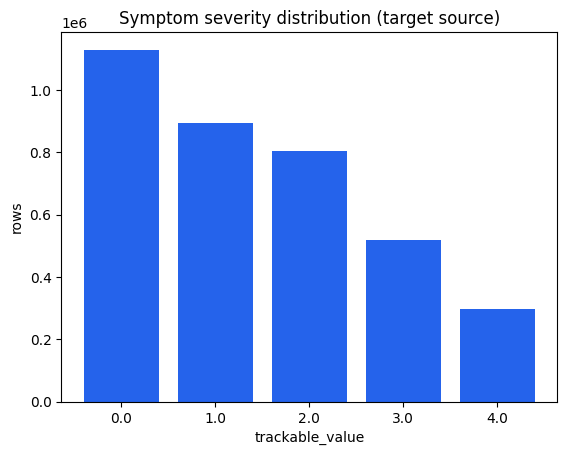

mean 1.439 | median 1.0


In [3]:
h = prof['symptom_value_hist']
plt.bar(list(h.keys()), list(h.values()), color='#2563eb')
plt.title('Symptom severity distribution (target source)')
plt.xlabel('trackable_value'); plt.ylabel('rows'); plt.show()
print('mean', prof['symptom_value_pct']['mean'], '| median', prof['symptom_value_pct']['median'])

## 2b. Descriptive profile of the raw export

Sections 1 and 2 quantify volume and the prediction target. The cells here describe
*content*: which symptoms, conditions, and treatments people log most, who the users
are, and how conditions cluster together. Everything below reads the same
`reports/profile_result.json` produced by `src/profile_data.py` over the full export,
so the notebook stays fast. These are descriptive statistics, not modeling inputs, so
the train-only leakage rule does not apply to them.

### Most-logged trackables by type
Row counts per `trackable_name` for the three modeling-relevant types. Names are free
text, so near-duplicates such as `Fatigue` and `Fatigue and tiredness` coexist; this is
the raw vocabulary the daily panel later collapses into per-type counts and means.

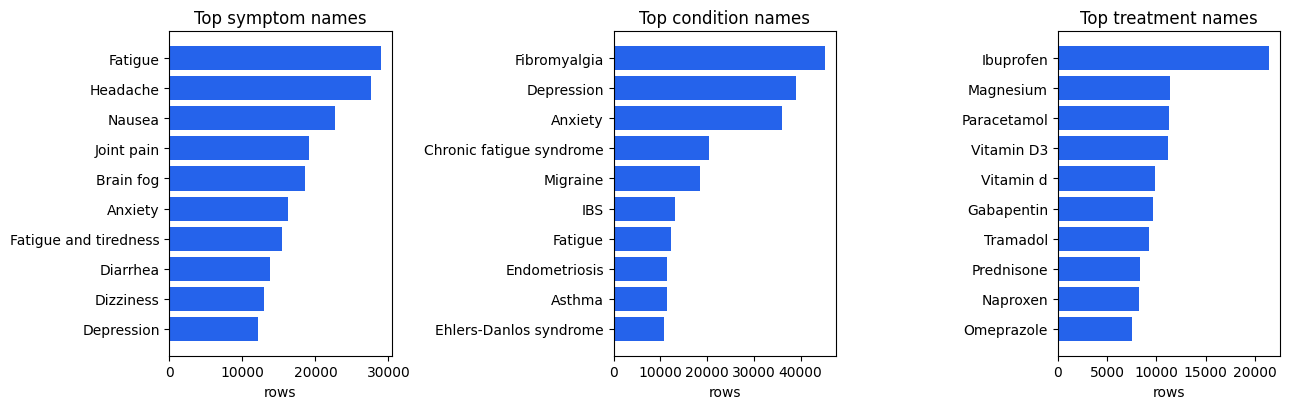

distinct names by type: {'Condition': 8453, 'Food': 8693, 'HBI': 1, 'Symptom': 9148, 'Tag': 9545, 'Treatment': 8155, 'Weather': 6}


In [4]:
FIG = ROOT / 'reports' / 'figures'; FIG.mkdir(parents=True, exist_ok=True)
top = prof['top_trackable_names']
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, t in zip(axes, ['Symptom', 'Condition', 'Treatment']):
    s = pd.Series(top[t]).head(10)[::-1]
    ax.barh(s.index, s.values, color='#2563eb')
    ax.set_title(f'Top {t.lower()} names'); ax.set_xlabel('rows')
fig.tight_layout(); fig.savefig(FIG / '08_top_trackable_names.png', dpi=110); plt.show()
print('distinct names by type:', prof['n_trackable_names_by_type'])

### Who is in the data
Sex split, the most common countries, and the cleaned age summary. These counts are over
rows, not users, so heavy daily loggers weigh more heavily; the prevalence section below
switches to distinct users for the condition view.

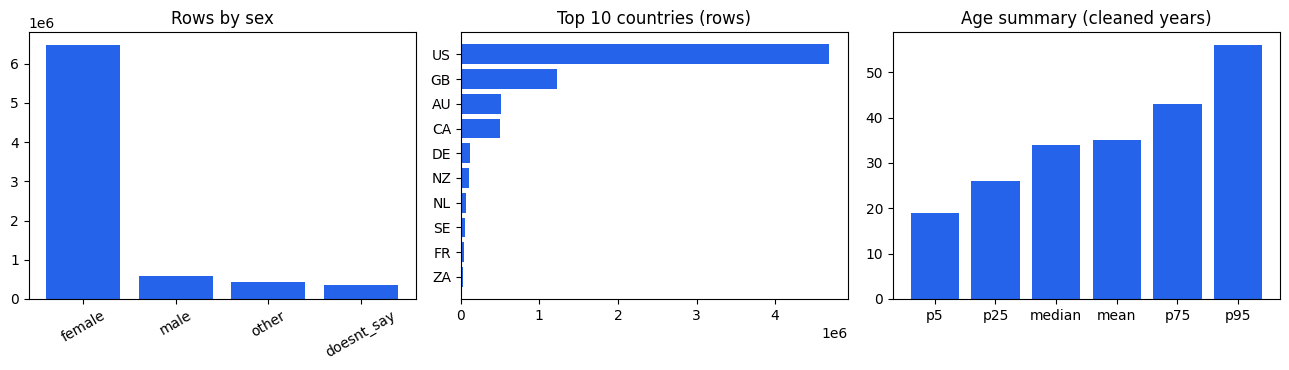

users: 42,283 | countries: 164 | age median 34, p5 to p95 19 to 56


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
sx = pd.Series(prof['sex_counts'])
axes[0].bar(sx.index, sx.values, color='#2563eb')
axes[0].set_title('Rows by sex'); axes[0].tick_params(axis='x', rotation=30)
co = pd.Series(prof['country_top20']).head(10)[::-1]
axes[1].barh(co.index, co.values, color='#2563eb'); axes[1].set_title('Top 10 countries (rows)')
a = prof['age_pct']
axes[2].bar(['p5', 'p25', 'median', 'mean', 'p75', 'p95'],
            [a['p5'], a['p25'], a['median'], a['mean'], a['p75'], a['p95']], color='#2563eb')
axes[2].set_title('Age summary (cleaned years)')
fig.tight_layout(); fig.savefig(FIG / '09_demographics.png', dpi=110); plt.show()
print(f"users: {prof['n_users']:,} | countries: {prof['n_countries']} | "
      f"age median {a['median']:.0f}, p5 to p95 {a['p5']:.0f} to {a['p95']:.0f}")

### Condition prevalence (distinct users)
Row counts overweight users who log every day. Counting each user once gives the cohort
size per condition, which is the comparable measure of how common a condition is in the
population and a more honest basis for any per-condition analysis.

users reporting at least one condition: 38,308


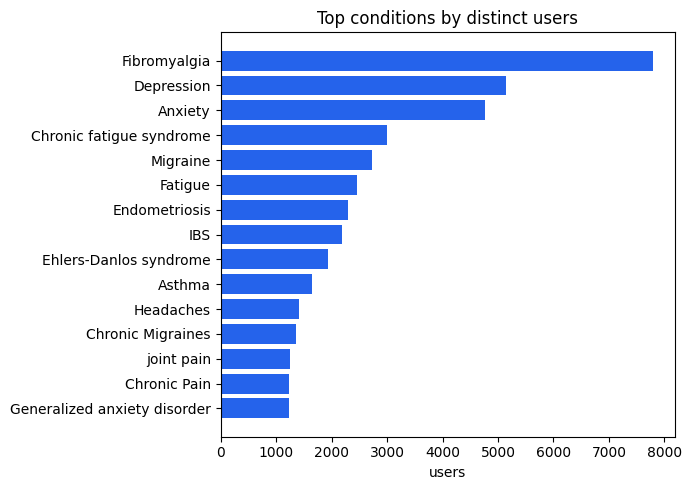

In [6]:
prev = pd.Series(prof['condition_prevalence_users'])
print(f"users reporting at least one condition: {prof['n_users_with_condition']:,}")
fig, ax = plt.subplots(figsize=(7, 5))
s = prev.head(15)[::-1]
ax.barh(s.index, s.values, color='#2563eb')
ax.set_title('Top conditions by distinct users'); ax.set_xlabel('users')
fig.tight_layout(); fig.savefig(FIG / '10_condition_prevalence.png', dpi=110); plt.show()

### Condition co-occurrence
Among the 15 most prevalent conditions, the number of users carrying each pair together.
The autoimmune and chronic-pain conditions cluster (anxiety with depression, fibromyalgia
with chronic fatigue), which is why a per-condition cohort model is a sensible step beyond
the pooled regression in section 6.

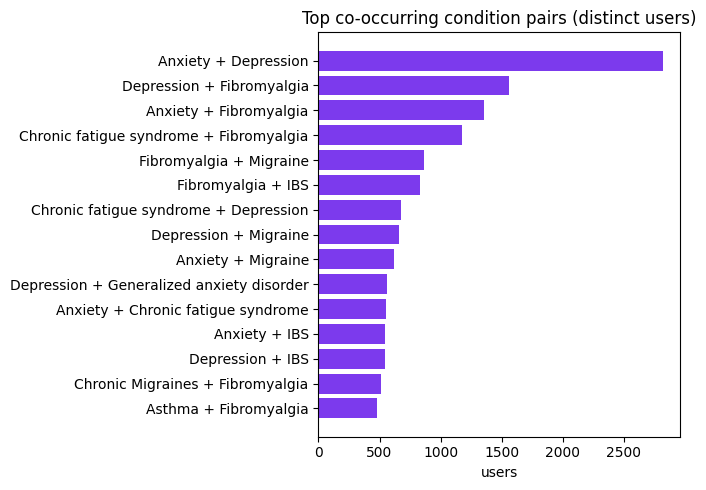

In [7]:
pairs = pd.Series(prof['condition_cooccurrence_users'])
fig, ax = plt.subplots(figsize=(7, 5))
s = pairs.head(15)[::-1]
ax.barh(s.index, s.values, color='#7c3aed')
ax.set_title('Top co-occurring condition pairs (distinct users)'); ax.set_xlabel('users')
fig.tight_layout(); fig.savefig(FIG / '11_condition_cooccurrence.png', dpi=110); plt.show()

## 3. Daily panel: one row per (user, day)
Built by `src/build_panel.py`: long event log → daily features.

In [8]:
p = pd.read_csv(PANEL, parse_dates=['date'])
print(p.shape, '| users:', p['user_id'].nunique())
p.head()

(383228, 18) | users: 42283


,user_id,date,sym_count,sym_mean,sym_max,cond_count,cond_mean,treat_count,food_count,tag_count,humidity,precip_intensity,pressure,temperature_max,temperature_min,age,sex,country
0,QEVuQwEA++2fi8XAwh3BnSEwL172Dg==,2019-08-25,0,NaN,NaN,0,NaN,0,0,0,65.0,0.0000,1023.0,77.0,61.0,42.0,female,US
1,QEVuQwEA++2fi8XAwh3BnSEwL172Dg==,2019-08-26,0,NaN,NaN,0,NaN,0,0,0,73.0,0.0000,1021.0,74.0,62.0,42.0,female,US
2,QEVuQwEA++2fi8XAwh3BnSEwL172Dg==,2019-08-27,0,NaN,NaN,0,NaN,0,0,0,76.0,0.0000,1017.0,78.0,64.0,42.0,female,US
3,QEVuQwEA++2fi8XAwh3BnSEwL172Dg==,2019-08-28,4,3.750000,4.0,1,4.0,2,2,2,82.0,0.0003,1012.0,79.0,67.0,42.0,female,US
4,QEVuQwEA++2fi8XAwh3BnSEwL172Dg==,2019-08-29,7,2.142857,4.0,1,4.0,1,0,0,62.0,0.0001,1015.0,84.0,64.0,42.0,female,US


### Missingness in the daily panel (Step 4)
Column-wise missing counts and percentages, plus whether the weather variables go
missing together. Weather is logged by only a small share of users, so those columns
are largely absent, and that absence is itself a signal about who tracks what rather
than something to impute away without thought.

In [9]:
# Template Step 4: missingness audit on the daily panel.
# The raw profile reports null rates on the long export; the panel is where the model
# actually trains, and the weather block is mostly empty because only a minority of
# users log weather. Absence here is informative, not noise to fill blindly.
miss = pd.DataFrame({
    'missing_count': p.isnull().sum(),
    'missing_pct': (p.isnull().mean() * 100).round(1),
}).sort_values('missing_pct', ascending=False)
print(miss[miss.missing_count > 0])

wx = ['temperature_max', 'temperature_min', 'humidity', 'pressure', 'precip_intensity']
print('\nweather co-missingness (1.0 = always missing together):')
print(p[wx].isnull().corr().round(2))

                  missing_count  missing_pct
precip_intensity         151229         39.5
temperature_min          151024         39.4
temperature_max          151024         39.4
pressure                 151024         39.4
humidity                 151024         39.4
cond_mean                101746         26.5
sym_mean                  74038         19.3
sym_max                   74038         19.3
age                       19813          5.2
country                   16861          4.4
sex                        7234          1.9

weather co-missingness (1.0 = always missing together):
                  temperature_max  temperature_min  humidity  pressure  \
temperature_max               1.0              1.0       1.0       1.0   
temperature_min               1.0              1.0       1.0       1.0   
humidity                      1.0              1.0       1.0       1.0   
pressure                      1.0              1.0       1.0       1.0   
precip_intensity              1.0

### Data-quality check: `age` (fixed upstream)
Raw `age` contains impossible values, both negatives and birth years such as 2018.
`src/build_panel.py` sets anything outside [5, 120] to NaN before the split, so the
panel loaded here is already clean. Out-of-range values become missing rather than
being clipped to a bound, which avoids piling artificial spikes onto the edges. The
cell below confirms the fix held.

In [10]:
print('panel age range:', p['age'].min(), '->', p['age'].max())
print('rows still outside [5,120]:', int(((p['age'] < 5) | (p['age'] > 120)).sum()))
print('age missing (incl. fixed impossibles):', int(p['age'].isnull().sum()))
p['age'].describe()

panel age range: 5.0 -> 118.0
rows still outside [5,120]: 0
age missing (incl. fixed impossibles): 19813


count    363415.000000
mean         34.980606
std          11.368502
min           5.000000
25%          26.000000
50%          33.000000
75%          42.000000
max         118.000000
Name: age, dtype: float64

## 4. Check-in volume over time
Sparse, irregular per-user time series, which motivates a temporal split and a
strictly-next-calendar-day target.

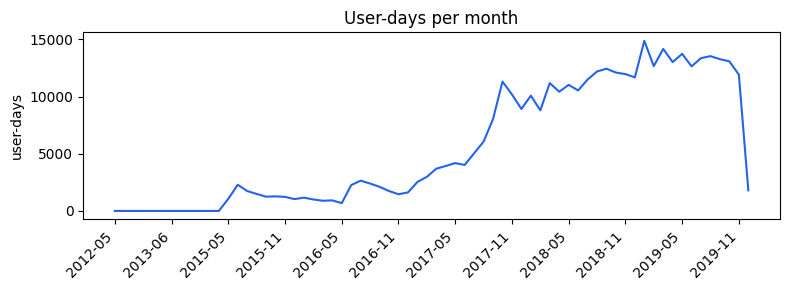

In [11]:
by = p['date'].dt.to_period('M').value_counts().sort_index()
plt.figure(figsize=(8,3)); plt.plot([str(x) for x in by.index], by.values, color='#2563eb')
plt.xticks(range(0, len(by), 6), [str(by.index[i]) for i in range(0, len(by), 6)], rotation=45, ha='right')
plt.title('User-days per month'); plt.ylabel('user-days'); plt.tight_layout(); plt.show()

## 5. Build the next-day target + lagged history (H1 / H2 features)

In [12]:
p = p.sort_values(['user_id', 'date'])
g = p.groupby('user_id')['sym_mean']
for k in (1, 2, 3):
    p[f'lag{k}_sym'] = g.shift(k)
# next calendar day's mean severity
nxt = p[['user_id', 'date', 'sym_mean']].copy()
nxt['date'] -= pd.Timedelta(days=1)
p = p.merge(nxt.rename(columns={'sym_mean': 'target'}), on=['user_id', 'date'], how='left')
data = p[p['target'].notna() & p['sym_mean'].notna()]
print('modeling rows:', len(data))
data[['sym_mean', 'lag1_sym', 'lag2_sym', 'lag3_sym', 'target']].corr()['target']

modeling rows: 214388


sym_mean    0.790930
lag1_sym    0.751834
lag2_sym    0.732244
lag3_sym    0.723776
target      1.000000
Name: target, dtype: float64

### Feature summary table (Step 5)
Type, missingness, cardinality, and a one-line description for each model input. This
is the map the cleaning and modelling decisions below refer back to.

In [13]:
# Template Step 5: feature summary table for the model inputs.
desc = {
    'sym_mean': 'mean symptom severity logged today (0-4)',
    'lag1_sym': 'mean severity 1 recorded day back',
    'lag2_sym': 'mean severity 2 recorded days back',
    'lag3_sym': 'mean severity 3 recorded days back',
    'sym_count': 'number of symptoms logged today',
    'cond_mean': 'mean condition severity today (0-4)',
    'treat_count': 'number of treatments logged today',
    'food_count': 'number of foods logged today',
    'tag_count': 'number of lifestyle tags logged today',
    'temperature_max': 'daily maximum temperature',
    'temperature_min': 'daily minimum temperature',
    'humidity': 'daily humidity',
    'pressure': 'daily barometric pressure',
    'precip_intensity': 'daily precipitation intensity',
    'age': 'user age, cleaned to [5, 120]',
}
feats = list(desc)
summary = pd.DataFrame({
    'feature': feats,
    'dtype': [str(data[c].dtype) for c in feats],
    'missing_pct': [round(data[c].isnull().mean() * 100, 1) for c in feats],
    'n_unique': [int(data[c].nunique()) for c in feats],
    'description': [desc[c] for c in feats],
})
summary

,feature,dtype,missing_pct,n_unique,description
0,sym_mean,float64,0.0,3354,mean symptom severity logged today (0-4)
1,lag1_sym,float64,9.8,3229,mean severity 1 recorded day back
2,lag2_sym,float64,13.5,3195,mean severity 2 recorded days back
3,lag3_sym,float64,16.6,3173,mean severity 3 recorded days back
4,sym_count,int64,0.0,126,number of symptoms logged today
5,cond_mean,float64,15.8,778,mean condition severity today (0-4)
6,treat_count,int64,0.0,52,number of treatments logged today
7,food_count,int64,0.0,47,number of foods logged today
8,tag_count,int64,0.0,42,number of lifestyle tags logged today
9,temperature_max,float64,39.4,137,daily maximum temperature


## 6. Leakage-safe temporal split + model vs naive baseline
Mirrors `src/make_features.py`. Preprocessing is fit on **train only** via a Pipeline.

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import mean_squared_error

FEATURES = ['sym_mean','lag1_sym','lag2_sym','lag3_sym','sym_count','cond_mean',
            'treat_count','food_count','tag_count','temperature_max','temperature_min',
            'humidity','pressure','precip_intensity','age']
SPLIT = pd.Timestamp('2019-01-01')
tr, te = data[data['date'] < SPLIT], data[data['date'] >= SPLIT]

naive = np.sqrt(mean_squared_error(te['target'], te['sym_mean']))
pipe = Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler()), ('m', LinearRegression())])
cv = -cross_val_score(pipe, tr[FEATURES], tr['target'], cv=GroupKFold(5),
                      groups=tr['user_id'], scoring='neg_root_mean_squared_error')
pipe.fit(tr[FEATURES], tr['target'])
test_rmse = np.sqrt(mean_squared_error(te['target'], pipe.predict(te[FEATURES])))
print(f'naive baseline RMSE : {naive:.3f}')
print(f'grouped-CV RMSE     : {cv.mean():.3f} ± {cv.std():.3f}')
print(f'linreg test RMSE    : {test_rmse:.3f}  ({(naive-test_rmse)/naive*100:+.1f}% vs naive)')
print('H1 supported:', test_rmse < naive)

naive baseline RMSE : 0.538
grouped-CV RMSE     : 0.480 ± 0.011
linreg test RMSE    : 0.472  (+12.3% vs naive)
H1 supported: True


### Regression diagnostics (Step 13)
Predicted-versus-actual and residual plots for the linear model on the 2019 hold-out.
The ordinal 0-4 target shows up as banding, so the question the plots answer is whether
residuals stay centred on zero across the predicted range rather than drifting at the
high or low end. Both charts are written to `reports/figures/`.

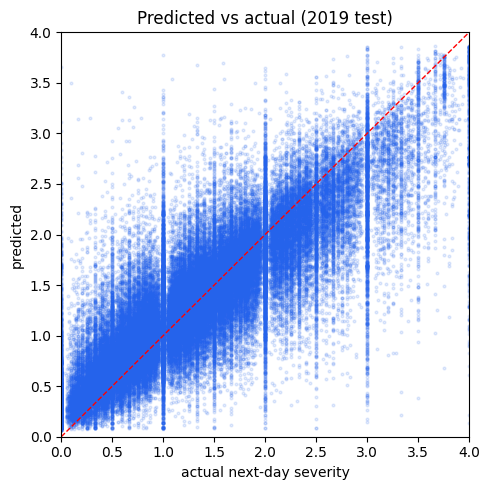

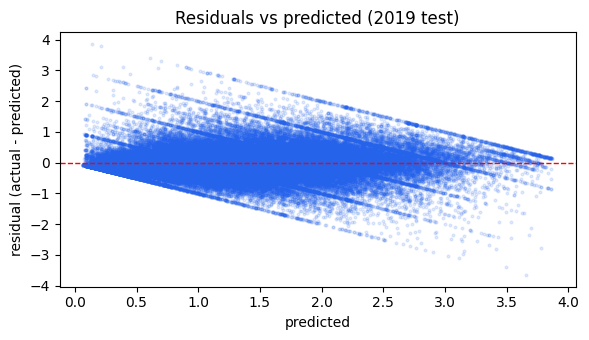

saved 06_pred_vs_actual.png and 07_residuals.png to /Users/violakempa/Data_Science_ToU/regression_health/reports/figures


In [15]:
# Template Step 13: regression diagnostics on the 2019 temporal test set.
FIG = ROOT / 'reports' / 'figures'; FIG.mkdir(parents=True, exist_ok=True)
pred = pipe.predict(te[FEATURES]); resid = te['target'].values - pred

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(te['target'], pred, s=4, alpha=0.12, color='#2563eb')
ax.plot([0, 4], [0, 4], 'r--', lw=1)
ax.set_xlim(0, 4); ax.set_ylim(0, 4)
ax.set_xlabel('actual next-day severity'); ax.set_ylabel('predicted')
ax.set_title('Predicted vs actual (2019 test)')
fig.tight_layout(); fig.savefig(FIG / '06_pred_vs_actual.png', dpi=110); plt.show()

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.scatter(pred, resid, s=4, alpha=0.12, color='#2563eb')
ax.axhline(0, color='r', ls='--', lw=1)
ax.set_xlabel('predicted'); ax.set_ylabel('residual (actual - predicted)')
ax.set_title('Residuals vs predicted (2019 test)')
fig.tight_layout(); fig.savefig(FIG / '07_residuals.png', dpi=110); plt.show()
print('saved 06_pred_vs_actual.png and 07_residuals.png to', FIG)

## 7. H2: symptom history vs environment
Compare the predictive power of the two feature blocks under the same grouped CV.

In [16]:
def block_rmse(cols):
    return -cross_val_score(pipe, tr[cols], tr['target'], cv=GroupKFold(5),
                            groups=tr['user_id'], scoring='neg_root_mean_squared_error').mean()
hist = block_rmse(['sym_mean','lag1_sym','lag2_sym','lag3_sym'])
env  = block_rmse(['temperature_max','temperature_min','humidity','pressure','precip_intensity'])
print(f'history-only CV RMSE     : {hist:.3f}')
print(f'environment-only CV RMSE : {env:.3f}')
print('H2 supported (history stronger):', hist < env)

history-only CV RMSE     : 0.481
environment-only CV RMSE : 0.832
H2 supported (history stronger): True


---
**Takeaways:** H1 supported (model beats the naive baseline by ~12%); H2 supported
(a patient's recent symptom history predicts tomorrow far better than the weather).
Next: standardize `trackable_name`, add per-user baseline severity, try per-condition cohorts.